# ReID 数据增强交互式可视化

本 notebook 面向论文插图制作，展示：随机裁剪、随机灰度化、随机色彩抖动、PCA 光照/色彩扰动、随机擦除，以及 RandomPatch 跨图随机补丁遮挡。除灰度化外，核心参数与本目录 `transforms.py` 保持一致。

使用说明：依次运行全部单元；在交互面板中拖动参数或点击“重新采样”。最后一个单元可导出 300 dpi 的论文对比图。随机增强具有随机性，固定 `seed` 可复现实验。

In [103]:
# 基础依赖与项目路径。Notebook 可从仓库根目录或 torchreid/data 目录启动。
from pathlib import Path
import copy, random, sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import (
    ColorJitter, RandomGrayscale, RandomRotation, RandAugment, InterpolationMode,
    ToTensor, ToPILImage
)

HERE = Path.cwd().resolve()
REPO = HERE if (HERE / 'torchreid').exists() else HERE.parents[1]
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# 直接复用训练代码中的实现，确保可视化与实际训练一致。
from torchreid.data.transforms import (
    Random2DTranslation, ColorAugmentation, RandomErasing, RandomPatch
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False
print('Repository:', REPO)

Repository: D:\code\deep-person-reid-master


## 1. 读取样例图与 RandomPatch 参考图

默认自动搜索 `reid-data`。也可以把 `IMAGE_PATH` 改为任意图片的绝对路径。RandomPatch 必须先从其他图像收集补丁，因此这里同时建立参考图列表。

Sample: D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_021\tiger_021_video_021_0003.jpg
RandomPatch reference images: 64


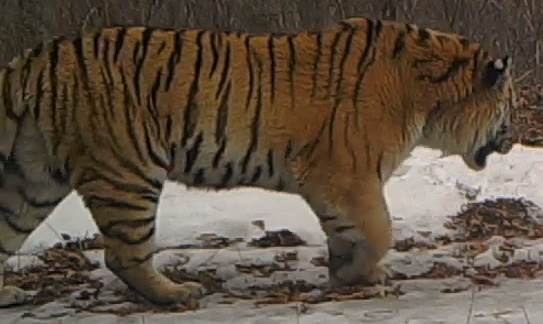

In [104]:
#IMAGE_PATH = None  # 例如：r'D:/data/tiger/example.jpg'；None 表示自动选择
IMAGE_PATH =r'D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_021\tiger_021_video_021_0003.jpg'
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
data_root = REPO / 'reid-data'
image_paths = sorted(p for p in data_root.rglob('*') if p.suffix.lower() in IMAGE_EXTS)
if IMAGE_PATH is not None:
    sample_path = Path(IMAGE_PATH)
elif image_paths:
    sample_path = image_paths[0]
else:
    raise FileNotFoundError('未找到样例图，请在 IMAGE_PATH 中填写图片路径。')

reference_paths = [p for p in image_paths if p != sample_path][:64]
source_img = Image.open(sample_path).convert('RGB')
print('Sample:', sample_path)
print('RandomPatch reference images:', len(reference_paths))
display(source_img)
#display(source_img.resize((256, 256)))

## 2. 增强方法封装

- **随机裁剪**：先放大到目标尺寸的 1.125 倍，再随机裁回目标尺寸，对应 `Random2DTranslation`。
- **随机灰度化**：按概率转换为三通道灰度图。
- **随机色彩抖动**：与 `transforms.py` 默认配置一致：亮度 0.2、对比度 0.15、饱和度 0、色相 0。
- **ColorAugmentation**：沿 ImageNet RGB 主成分方向加入随机扰动，即 AlexNet 风格 PCA lighting。
- **随机擦除**：在 Tensor 上用均值填充随机矩形区域。为直观显示，这里在 `[0,1]` Tensor 上执行；训练流水线中它位于 Normalize 之后。
- **RandomPatch**：从其他图像建立补丁池，再把随机补丁贴到当前图像，模拟跨图遮挡。

In [105]:
TARGET_H, TARGET_W = 128, 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
AUGMENTATION_TITLES = {
    '随机裁剪': 'Random Crop',
    '随机灰度化': 'Random Grayscale',
    '随机旋转': 'Random Rotation',
    '随机色彩抖动': 'Color Jitter',
    'PCA 光照扰动': 'PCA Lighting',
    '随机擦除': 'Random Erasing',
    'RandomPatch 跨图遮挡': 'RandomPatch Cross-image Occlusion',
    'RandAugment (Cubuk)': 'RandAugment ',
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

def build_patch_augmenter(ref_paths, seed=0, patch_max_area=0.35):
    # min_sample_size=1 仅用于演示；训练代码默认值为 100。
    aug = RandomPatch(prob_happen=1.0, min_sample_size=1,
                      patch_min_area=0.02, patch_max_area=patch_max_area)
    set_seed(seed)
    for path in ref_paths:
        ref = Image.open(path).convert('RGB').resize((TARGET_W, TARGET_H))
        # 暂时禁止粘贴，只让 __call__ 从每张参考图采集一个补丁。
        old_prob = aug.prob_happen
        aug.prob_happen = 0.0
        aug(ref.copy())
        aug.prob_happen = old_prob
    return aug

def apply_augmentation(img, method, seed=0, probability=1.0,
                       crop_scale=1.125, brightness=0.2, contrast=0.15,
                       erase_max_area=0.40, patch_max_area=0.35,
                       randaugment_num_ops=2, randaugment_magnitude=9,
                       rotation_degrees=15):
    set_seed(seed)
    base = img.convert('RGB').resize((TARGET_W, TARGET_H))
    if method == '原图':
        return base
    if method == '随机裁剪':
        # 项目类固定使用 1.125；crop_scale 供论文可视化时比较尺度。
        if abs(crop_scale - 1.125) < 1e-8:
            return Random2DTranslation(TARGET_H, TARGET_W, p=probability)(img.copy())
        if random.random() > probability:
            return base
        w, h = round(TARGET_W * crop_scale), round(TARGET_H * crop_scale)
        enlarged = img.resize((w, h), Image.BILINEAR)
        x, y = random.randint(0, w-TARGET_W), random.randint(0, h-TARGET_H)
        return enlarged.crop((x, y, x+TARGET_W, y+TARGET_H))
    if method == '随机灰度化':
        return RandomGrayscale(p=probability)(base)
    if method == '随机旋转':
        if random.random() > probability:
            return base
        return RandomRotation(
            degrees=(-rotation_degrees, rotation_degrees),
            interpolation=InterpolationMode.BILINEAR,
            fill=(0, 0, 0),
        )(base)
    if method == '随机色彩抖动':
        if random.random() > probability:
            return base
        return ColorJitter(brightness=brightness, contrast=contrast,
                           saturation=0, hue=0)(base)
    if method == 'PCA 光照扰动':
        tensor = ColorAugmentation(p=probability)(ToTensor()(base))
        return ToPILImage()(tensor.clamp(0, 1))
    if method == '随机擦除':
        tensor = ToTensor()(base)
        erased = RandomErasing(probability=probability, sh=erase_max_area,
                               mean=IMAGENET_MEAN)(tensor.clone())
        return ToPILImage()(erased.clamp(0, 1))
    if method == 'RandomPatch 跨图遮挡':
        if not reference_paths:
            warnings.warn('没有其他参考图，RandomPatch 无法建立跨图补丁池。')
            return base
        aug = build_patch_augmenter(reference_paths, seed, patch_max_area)
        aug.prob_happen = probability
        set_seed(seed + 10000)
        return aug(base.copy())
    if method == 'RandAugment (Cubuk)':
        # Cubuk 等人的 RandAugment：从候选操作池均匀抽取 N 个操作，
        # 所有操作共享同一个离散强度 M；无需固定手工串联策略。
        if random.random() > probability:
            return base
        augmenter = RandAugment(
            num_ops=int(randaugment_num_ops),
            magnitude=int(randaugment_magnitude),
            num_magnitude_bins=31,
            interpolation=InterpolationMode.BILINEAR,
            fill=[0, 0, 0],
        )
        return augmenter(base)
    raise ValueError(method)

## 3. 单种增强批量输出：每张输入图生成一个结果

在 `INPUT_IMAGE_PATHS` 中放入一张或多张图片路径。每次运行一种增强时，每张输入图只随机增强一次，并以独立 PNG 文件保存；例如输入 4 张图片，就会保存该方法对应的 4 张结果，不再生成“原图 + 4 个随机结果”的拼接图。


In [106]:
# 可以填一个或多个路径；保留 [sample_path] 即使用上面自动找到的样例图。
INPUT_IMAGE_PATHS = [
    
    r'D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_051\tiger_051_video_051_0012.jpg',
    r'D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_057\tiger_057_video_057_0062.jpg',
    r'D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_058\tiger_058_video_058_0029.jpg',
    r'D:\code\deep-person-reid-master\reid-data\Wild_Tiger\train\tiger_075\tiger_075_video_075_0006.jpg',
]

METHOD_FOLDER_NAMES = {
    '随机裁剪': 'random_crop',
    '随机灰度化': 'random_grayscale',
    '随机旋转': 'random_rotation',
    '随机色彩抖动': 'color_jitter',
    'PCA 光照扰动': 'pca_lighting',
    '随机擦除': 'random_erasing',
    'RandomPatch 跨图遮挡': 'random_patch',
    'RandAugment (Cubuk)': 'randaugment_cubuk',
}

def load_input_images(paths):
    if isinstance(paths, (str, Path)):
        paths = [paths]
    items = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            warnings.warn(f'跳过不存在的图片：{path}')
            continue
        items.append((path, Image.open(path).convert('RGB')))
    if not items:
        raise ValueError('没有可读取的输入图片，请检查 INPUT_IMAGE_PATHS。')
    return items

def save_single_outputs(method, image_paths=INPUT_IMAGE_PATHS, base_seed=100,
                        output_root=None, show=True, **augmentation_kwargs):
    """每张输入图只增强一次，并把结果分别保存为独立图片。"""
    items = load_input_images(image_paths)
    if output_root is None:
        output_root = REPO / 'torchreid' / 'data' / 'aug_output'
    method_dir = Path(output_root) / METHOD_FOLDER_NAMES.get(method, 'augmentation')
    method_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for index, (source_path, image) in enumerate(items, start=1):
        # 不同输入使用不同 seed；固定 base_seed 时可复现。
        seed = base_seed + index - 1
        result = apply_augmentation(
            image, method, seed=seed, probability=1.0,
            **augmentation_kwargs
        )
        save_path = method_dir / f'{source_path.stem}_{METHOD_FOLDER_NAMES.get(method, "augmented")}.png'
        # 遇到同名输入时加入序号，避免覆盖前一张结果。
        if save_path in saved_paths:
            save_path = method_dir / f'{source_path.stem}_{index:02d}_{METHOD_FOLDER_NAMES.get(method, "augmented")}.png'
        result.save(save_path)
        saved_paths.append(save_path)
        print(f'[{index}/{len(items)}] Saved: {save_path}')
        if show:
            display(result)
    return saved_paths


### 3.1 随机裁剪（独立运行）

每张输入图执行一次随机裁剪，并分别保存。


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_crop\tiger_051_video_051_0012_random_crop.png


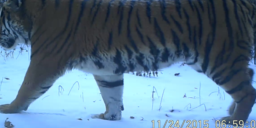

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_crop\tiger_057_video_057_0062_random_crop.png


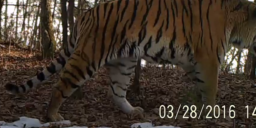

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_crop\tiger_058_video_058_0029_random_crop.png


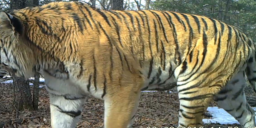

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_crop\tiger_075_video_075_0006_random_crop.png


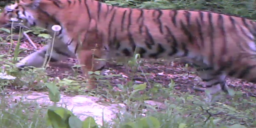

In [107]:
crop_paths = save_single_outputs(
    '随机裁剪', INPUT_IMAGE_PATHS, base_seed=100,
    crop_scale=1.125
)


### 3.2 随机灰度化（独立运行）


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_grayscale\tiger_051_video_051_0012_random_grayscale.png


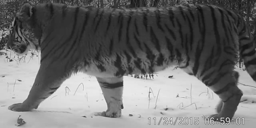

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_grayscale\tiger_057_video_057_0062_random_grayscale.png


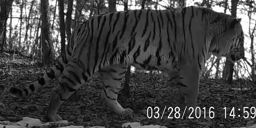

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_grayscale\tiger_058_video_058_0029_random_grayscale.png


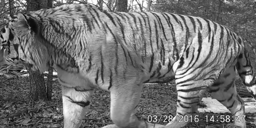

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_grayscale\tiger_075_video_075_0006_random_grayscale.png


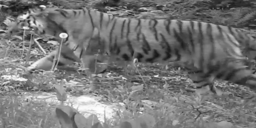

In [108]:
grayscale_paths = save_single_outputs(
    '随机灰度化', INPUT_IMAGE_PATHS, base_seed=200
)


### 3.3 随机旋转（独立运行）

默认在 -15° 到 +15° 范围内随机旋转，使用双线性插值，旋转后的空白区域填充为黑色。

[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_rotation\tiger_051_video_051_0012_random_rotation.png


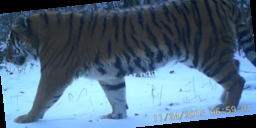

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_rotation\tiger_057_video_057_0062_random_rotation.png


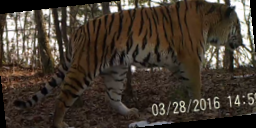

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_rotation\tiger_058_video_058_0029_random_rotation.png


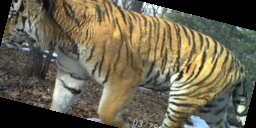

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_rotation\tiger_075_video_075_0006_random_rotation.png


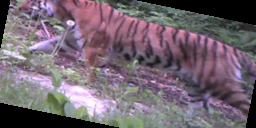

In [109]:
rotation_paths = save_single_outputs(
    '随机旋转', INPUT_IMAGE_PATHS, base_seed=110,
    rotation_degrees=15
)

### 3.4 随机色彩抖动（独立运行）


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\color_jitter\tiger_051_video_051_0012_color_jitter.png


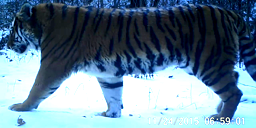

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\color_jitter\tiger_057_video_057_0062_color_jitter.png


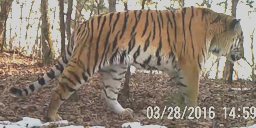

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\color_jitter\tiger_058_video_058_0029_color_jitter.png


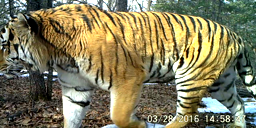

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\color_jitter\tiger_075_video_075_0006_color_jitter.png


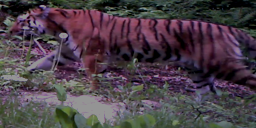

In [110]:
jitter_paths = save_single_outputs(
    '随机色彩抖动', INPUT_IMAGE_PATHS, base_seed=100,
    brightness=1.6, contrast=1.2
)


### 3.5 ColorAugmentation：PCA 光照变化（独立运行）


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\pca_lighting\tiger_051_video_051_0012_pca_lighting.png


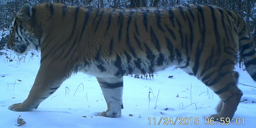

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\pca_lighting\tiger_057_video_057_0062_pca_lighting.png


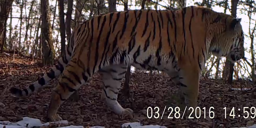

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\pca_lighting\tiger_058_video_058_0029_pca_lighting.png


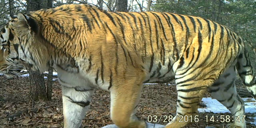

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\pca_lighting\tiger_075_video_075_0006_pca_lighting.png


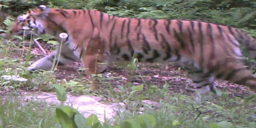

In [123]:
pca_paths = save_single_outputs(
    'PCA 光照扰动', INPUT_IMAGE_PATHS, base_seed=100
)


### 3.6 随机擦除（独立运行）


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_erasing\tiger_051_video_051_0012_random_erasing.png


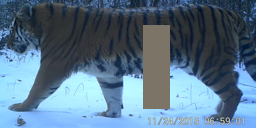

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_erasing\tiger_057_video_057_0062_random_erasing.png


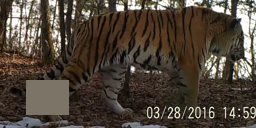

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_erasing\tiger_058_video_058_0029_random_erasing.png


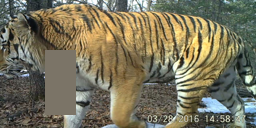

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_erasing\tiger_075_video_075_0006_random_erasing.png


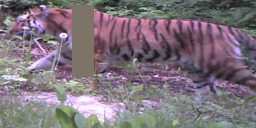

In [112]:
erasing_paths = save_single_outputs(
    '随机擦除', INPUT_IMAGE_PATHS, base_seed=330,
    erase_max_area=0.10
)


### 3.7 RandomPatch 跨图随机补丁遮挡（独立运行）


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_patch\tiger_051_video_051_0012_random_patch.png


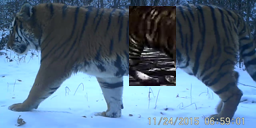

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_patch\tiger_057_video_057_0062_random_patch.png


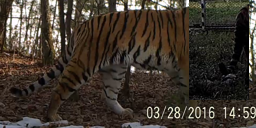

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_patch\tiger_058_video_058_0029_random_patch.png


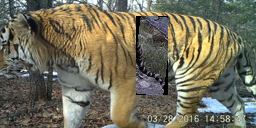

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\random_patch\tiger_075_video_075_0006_random_patch.png


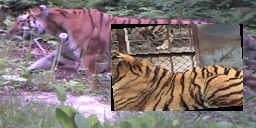

In [113]:
patch_paths = save_single_outputs(
    'RandomPatch 跨图遮挡', INPUT_IMAGE_PATHS, base_seed=600,
    patch_max_area=0.35
)


### 3.8 Cubuk RandAugment（独立运行）

RandAugment 从候选增强池中均匀随机选择 N 个操作，并让所有操作共享强度 M。默认采用 N=2、M=9、31 级强度区间。


[1/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\randaugment_cubuk\tiger_051_video_051_0012_randaugment_cubuk.png


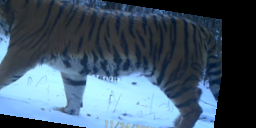

[2/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\randaugment_cubuk\tiger_057_video_057_0062_randaugment_cubuk.png


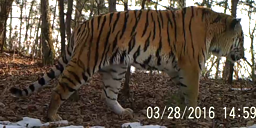

[3/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\randaugment_cubuk\tiger_058_video_058_0029_randaugment_cubuk.png


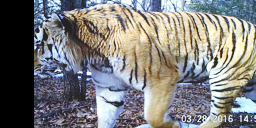

[4/4] Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\randaugment_cubuk\tiger_075_video_075_0006_randaugment_cubuk.png


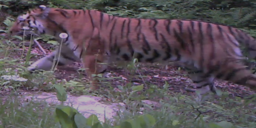

In [114]:
randaugment_paths = save_single_outputs(
    'RandAugment (Cubuk)', INPUT_IMAGE_PATHS, base_seed=700,
    randaugment_num_ops=2, randaugment_magnitude=9
)


## 4. 交互式单方法预览

选择方法并调整参数。`seed` 或“重新采样”按钮可切换随机结果。若内核缺少 `ipywidgets`，会自动显示静态预览；安装命令：`%pip install ipywidgets`。

In [ ]:
METHODS = ['随机裁剪', '随机灰度化', '随机旋转', '随机色彩抖动', 'PCA 光照扰动',
           '随机擦除', 'RandomPatch 跨图遮挡', 'RandAugment (Cubuk)']

def show_pair(method='随机裁剪', seed=7, probability=1.0, crop_scale=1.125,
              brightness=0.2, contrast=0.15, erase_max_area=0.40,
              patch_max_area=0.35, randaugment_num_ops=2,
              randaugment_magnitude=9, rotation_degrees=15):
    result = apply_augmentation(source_img, method, seed, probability,
                                crop_scale, brightness, contrast,
                                erase_max_area, patch_max_area,
                                randaugment_num_ops, randaugment_magnitude,
                                rotation_degrees)
    fig, axes = plt.subplots(1, 2, figsize=(6, 5), constrained_layout=True)
    axes[0].imshow(source_img.resize((TARGET_W, TARGET_H))); axes[0].set_title('Original')
    axes[1].imshow(result); axes[1].set_title(AUGMENTATION_TITLES.get(method, method))
    for ax in axes: ax.axis('off')
    output_dir = REPO / 'torchreid' / 'data' / 'aug_output'
    output_dir.mkdir(parents=True, exist_ok=True)
    interactive_path = output_dir / 'interactive_preview.png'
    fig.savefig(interactive_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Current interactive preview saved to:', interactive_path)

try:
    import ipywidgets as widgets
    from IPython.display import display
    controls = dict(
        method=widgets.Dropdown(options=METHODS, description='方法'),
        seed=widgets.IntSlider(value=7, min=0, max=999, description='seed'),
        probability=widgets.FloatSlider(value=1.0, min=0, max=1, step=.05, description='概率'),
        crop_scale=widgets.FloatSlider(value=1.125, min=1.0, max=1.5, step=.025, description='裁剪倍率'),
        brightness=widgets.FloatSlider(value=.2, min=0, max=.8, step=.05, description='亮度'),
        contrast=widgets.FloatSlider(value=.15, min=0, max=.8, step=.05, description='对比度'),
        erase_max_area=widgets.FloatSlider(value=.4, min=.05, max=.8, step=.05, description='擦除上限'),
        patch_max_area=widgets.FloatSlider(value=.35, min=.05, max=.7, step=.05, description='补丁上限'),
        randaugment_num_ops=widgets.IntSlider(value=2, min=1, max=10, description='N 操作数'),
        randaugment_magnitude=widgets.IntSlider(value=9, min=0, max=30, description='M 强度'),
        rotation_degrees=widgets.IntSlider(value=15, min=0, max=90, description='旋转角度'))
    output = widgets.interactive_output(show_pair, controls)
    display(widgets.VBox(list(controls.values())), output)
except ImportError:
    print('未安装 ipywidgets：当前显示静态预览。运行 `%pip install ipywidgets` 后重启内核可启用交互。')
    show_pair()

Output()

## 5. 论文用总览图（可复现并导出）

下面使用固定 seed 生成统一排版。建议在论文图注中说明每种增强仅作独立演示；实际训练可按 `build_transforms` 的顺序组合。

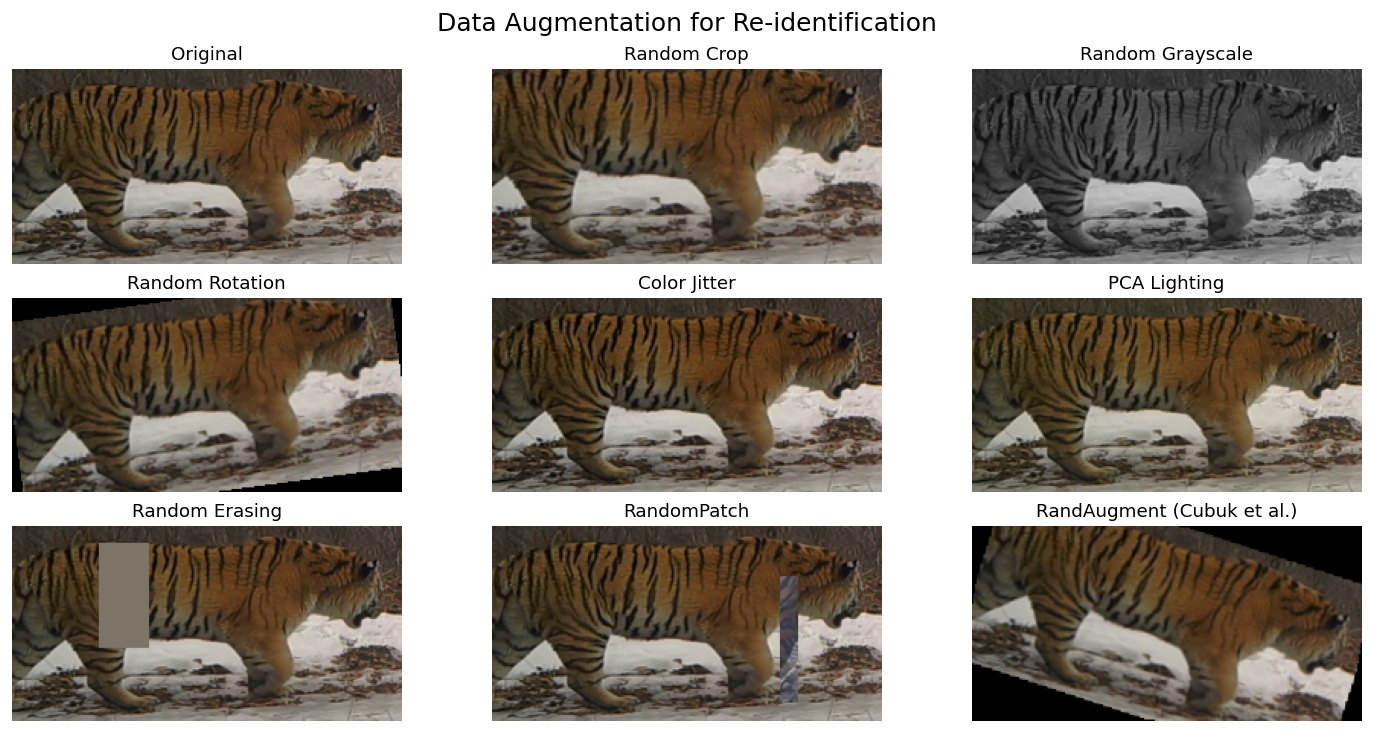

Saved: D:\code\deep-person-reid-master\torchreid\data\aug_output\augmentation_overview.png


In [116]:
PAPER_SEED = 23
paper_labels = ['Random Crop', 'Random Grayscale', 'Random Rotation', 'Color Jitter',
                'PCA Lighting', 'Random Erasing', 'RandomPatch',
                'RandAugment (Cubuk et al.)']
panels = [('Original', source_img.resize((TARGET_W, TARGET_H)))]
for i, (method, label) in enumerate(zip(METHODS, paper_labels)):
    panels.append((label, apply_augmentation(source_img, method, PAPER_SEED+i, 1.0)))

fig, axes = plt.subplots(3, 3, figsize=(12, 6), constrained_layout=True)
for ax, (title, picture) in zip(axes.flat, panels):
    ax.imshow(picture); ax.set_title(title, fontsize=11); ax.axis('off')
for ax in axes.flat[len(panels):]: ax.axis('off')
fig.suptitle('Data Augmentation for Re-identification', fontsize=15)
output_dir = REPO / 'torchreid' / 'data' / 'aug_output'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'augmentation_overview.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved:', output_path)

## 6. 与训练流水线一致的组合示例

训练配置可使用 `['random_flip', 'random_crop', 'random_patch', 'color_jitter', 'random_erase']`。注意：当前 `build_transforms` 尚未注册随机灰度化和 `ColorAugmentation` 名称，因此下面显式组合它们，便于研究不同策略。

In [117]:
# 一个可直接改参数的组合增强示例（返回用于模型输入的归一化 Tensor）。
from torchvision.transforms import Compose, Resize, RandomHorizontalFlip, Normalize
combined_transform = Compose([
    Resize((TARGET_H, TARGET_W)),
    RandomHorizontalFlip(p=0.5),
    RandomGrayscale(p=0.1),
    ColorJitter(brightness=0.2, contrast=0.15, saturation=0, hue=0),
    ToTensor(),
    ColorAugmentation(p=0.5),
    Normalize(IMAGENET_MEAN, [0.229, 0.224, 0.225]),
    RandomErasing(probability=0.5, mean=IMAGENET_MEAN),
])
set_seed(42)
model_input = combined_transform(source_img.copy())
print('Model input:', model_input.shape, model_input.dtype,
      'range=', (float(model_input.min()), float(model_input.max())))

Model input: torch.Size([3, 128, 256]) torch.float32 range= (-1.8781511783599854, 1.785969614982605)
